In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/moazeldsokyx
/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats
/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats/dataset
/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats/dataset/validation
/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats/dataset/validation/dogs
/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats/dataset/validation/cats
/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats/dataset/test
/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats/dataset/test/dogs
/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats/dataset/test/cats
/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats/dataset/train
/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats/dataset/train/dogs
/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats/dataset/train/cats


In [1]:
import tensorflow as tf

2026-04-16 07:59:47.558518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776326387.740830      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776326387.794510      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776326388.232003      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776326388.232048      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776326388.232051      55 computation_placer.cc:177] computation placer alr

In [2]:
from tensorflow import keras
from keras.models import Sequential
from keras import Input
from keras.layers import Dense,Conv2D, MaxPooling2D, Dropout, BatchNormalization, Flatten

In [3]:
train_dataset=keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats/dataset/train',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
  
)

test_dataset=keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats/dataset/test',
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
  
)

Found 20000 files belonging to 2 classes.


I0000 00:00:1776326449.531159      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 12461 files belonging to 2 classes.


In [5]:
def process(image,label):
    image = tf.cast(image/255.,tf.float32)
    return image,label

train = train_dataset.map(process)
test = test_dataset.map(process)

In [42]:
# creating a CNN architecture 

model = Sequential()

# Input(shape=(256,256,3))
model.add(Conv2D(16,kernel_size=(3,3),activation='relu',padding='valid'))
model.add(MaxPooling2D(pool_size = (2,2),strides=2,padding='valid'))

model.add(Conv2D(32,kernel_size=(3,3),activation='relu',padding='valid'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),activation='relu',padding='valid'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),activation='relu',padding='valid'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(64,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

        

In [44]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [46]:
history = model.fit(train,epochs=10,validation_data=test)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.6207 - loss: 0.6369 - val_accuracy: 0.7100 - val_loss: 0.5725
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.7620 - loss: 0.4848 - val_accuracy: 0.8091 - val_loss: 0.4153
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.8150 - loss: 0.3955 - val_accuracy: 0.7721 - val_loss: 0.4741
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.8520 - loss: 0.3344 - val_accuracy: 0.8408 - val_loss: 0.3524
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.8846 - loss: 0.2647 - val_accuracy: 0.8391 - val_loss: 0.3876
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.9170 - loss: 0.1996 - val_accuracy: 0.8300 - val_loss: 0.4184
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.9445 - loss: 0.1446 - val_accuracy: 0.8504 - val_loss: 0.4839
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.9589 - loss: 0.1050 - 

In [47]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,134,757 (19.59 MB)

 Trainable params: 1,711,585 (6.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,423,172 (13.06 MB)

[]

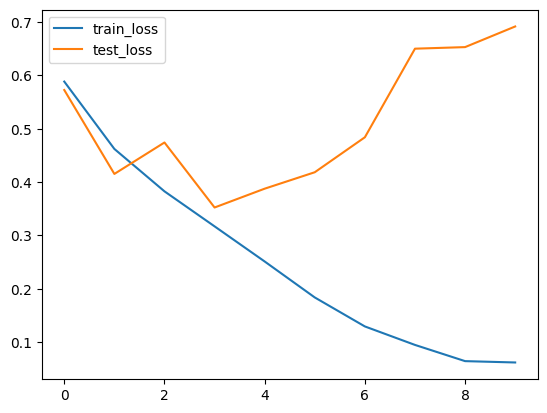

In [48]:
import matplotlib.pyplot as plt

# before applying dropouts
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='test_loss')
plt.legend()
plt.plot()

[]

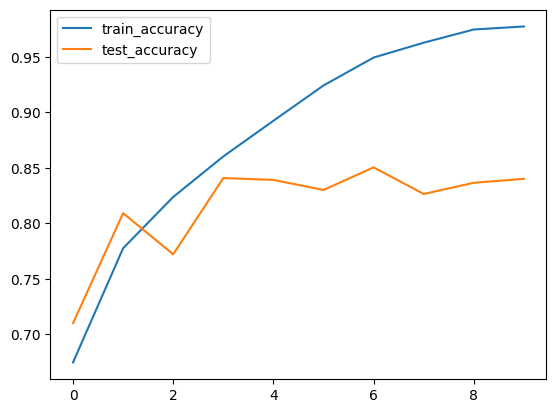

In [49]:
# before applying dropouts
plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='test_accuracy')
plt.legend()
plt.plot()

In [42]:
# creating a CNN architecture w/ dropout and BatchNormalization and Regularization

model = Sequential()

Input(shape=(256,256,3))
model.add(Conv2D(16,kernel_size=(3,3),activation='relu',padding='valid'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2),strides=2,padding='valid'))

model.add(Conv2D(32,kernel_size=(3,3),activation='relu',padding='valid',bias_regularizer='l2'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),activation='relu',padding='valid',bias_regularizer='l2'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),activation='relu',padding='valid',bias_regularizer='l2'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(64,activation='relu',kernel_regularizer='l2'))
model.add(Dropout(0.1))

model.add(Dense(128,activation='relu',kernel_regularizer='l2'))
model.add(Dropout(0.1))

model.add(Dense(256,activation='relu',kernel_regularizer='l2'))
model.add(Dropout(0.1))

model.add(Dense(1,activation='sigmoid'))



model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(train,epochs=11,validation_data = test)


Epoch 1/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.6125 - loss: 2.8240 - val_accuracy: 0.7071 - val_loss: 0.9663
Epoch 2/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.7683 - loss: 0.7867 - val_accuracy: 0.8064 - val_loss: 0.5881
Epoch 3/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8238 - loss: 0.5620 - val_accuracy: 0.7909 - val_loss: 0.6026
Epoch 4/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.8659 - loss: 0.4962 - val_accuracy: 0.8585 - val_loss: 0.5241
Epoch 5/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.8873 - loss: 0.4737 - val_accuracy: 0.8520 - val_loss: 0.5182
Epoch 6/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8955 - loss: 0.4376 - val_accuracy: 0.8919 - val_loss: 0.4625
Epoch 7/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9139 - loss: 0.4073 - val_accuracy: 0.8913 - val_loss: 0.4341
Epoch 8/11
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9235 - loss: 0.3839 - 

In [131]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_47 (Conv2D)              │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 254, 254, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 125, 125, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,236,133 (19.97 MB)

 Trainable params: 1,745,217 (6.66 MB)

 Non-trainable params: 480 (1.88 KB)

 Optimizer params: 3,490,436 (13.31 MB)

[]

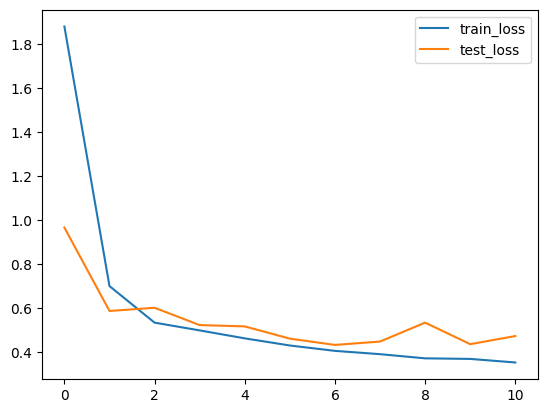

In [43]:
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='test_loss')
plt.legend()
plt.plot()

[]

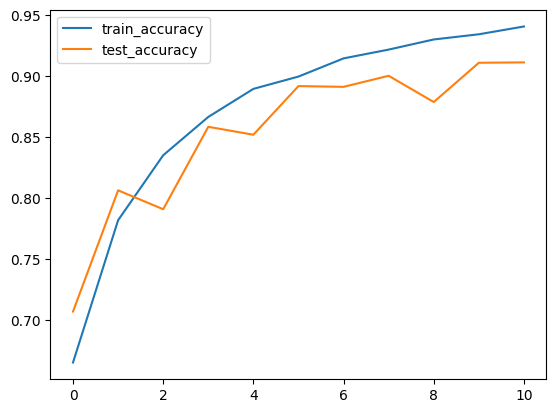

In [44]:
plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='test_accuracy')
plt.legend()
plt.plot()

In [46]:
import cv2

In [125]:

image = cv2.imread('/kaggle/input/datasets/moazeldsokyx/dogs-vs-cats/dataset/validation/dogs/dog.20.jpg')

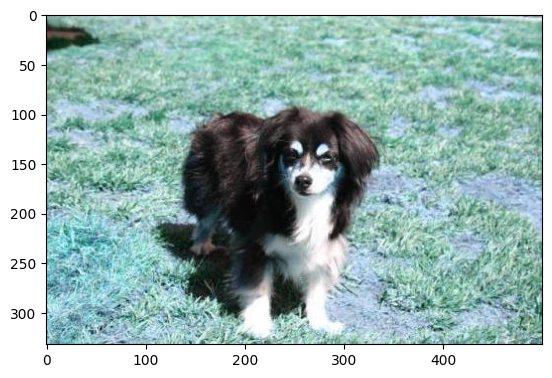

In [126]:
plt.imshow(image)

In [127]:
image.shape

(332, 500, 3)

In [128]:
image = cv2.resize(image,(256,256))

In [129]:
input_data = image.reshape(1,256,256,3)

In [130]:
model.predict(input_data)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


np.float32(1.0)